# Wine Value-for-Money

*Tasting note → VFM score (0–99)*

**Dataset:** `spawn99/wine-reviews` (~281K reviews, CC BY-NC-SA 4.0)
**Target:** `vfm` = log(points/price) min-max scaled on fixed analytic bounds → integer 0–99
(`utils/vfm.py` — stateless, reproducible from curation constants alone)
**Curation:** points 80–100, price $4–250 (≈91.6% of the market), description 100–2,000 chars

| Part | Content |
|---|---|
| 1 | Curation, VFM derivation, EDA suite, splits, optional push to Hub |
| 2 | Pre-processing: deterministic input assembly (+ optional LLM rewrite ablation) |
| 3 | Evaluation harness, baselines, traditional ML |
| 4 | Deep neural network + frontier zero-shot (composite path) |
| 5 | Fine-tuning a frontier model |
| 6 | Deterministic verdict layer demo (bargain / fair / overpriced) |

- **Target redesigned**
    Rejected raw `points/price` ratio (unstable, non-standard scale); adopted **VFM** = `log(points/price)` min-max scaled on fixed analytic bounds → integer **0–99**, deterministic, stateless, reproducible from curation constants alone (`utils/vfm.py`)

- **Curation**
    `spawn99/wine-reviews`, filtered to points 80–100, **price $4–250** (~91.6% of market), description 100–2,000 chars, deduped on (title, description) — **no subsampling/exclusion of any country** (full dataset used as-is)

- **Preprocessing**
    `TextAssembler` builds `wine.summary` = tasting note + Variety/Country/Province/Region/Winery, all flattened into one text block — **no separate categorical/dummy columns in any text-based model**. Title excluded by default (memorization-leakage risk). Optional Groq Batch API rewrite path built (`WineBatch`) for full-scale LLM rewrite of tasting notes.

- **EDA**
    VFM distribution, points/price/log-price, VFM by country/variety/province/region, and the price–points plane colored by VFM

- **Evaluation harness**
    `Tester`/`evaluate` — MAE ± 95% CI, R², color-coded scatter, **cumulative-error trend chart with shaded 95% CI band**

- **Model ladder built**
    Random/constant baselines → feature LR (top-5 country/variety dummies + note length) → bag-of-words LR → **combined BoW+dummies variants of LR/RF** → residual DNN (`VfmNet`, HashingVectorizer, plain standardization) → frontier LLM zero-shot, **two paths**: `frontier_composite` (model estimates points+price → frozen `compute_vfm`, fair comparison) and `frontier_direct` (cold 0–99 guess, expected weaker — VFM is our construct)

- **Fine-tuning rung — BLOCKED**
    OpenAI is winding down self-serve fine-tuning (May 2026 announcement).

## Part 0 — Setup

In [1]:
from __future__ import annotations

import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from openai import OpenAI

from utils.items import Wine
from utils.loaders import WineLoader
from utils.preprocessor import TextAssembler
from utils.evaluator import evaluate
from utils.deep_neural_network import VfmTrainer
from utils.vfm import compute_vfm, apply_vfm, VFM_LOG_MIN, VFM_LOG_MAX

load_dotenv(override=True)

True

In [2]:
# ── Global constants ──────────────────────────────────────────────────────────
SEED: int = 42
TRAIN_FRACTION: float = 0.8
VAL_FRACTION: float = 0.1          # test gets the remainder

FRONTIER_MODEL: str = "gpt-4.1"
FINE_TUNE_BASE_MODEL: str = "gpt-4.1-nano-2025-04-14"  # verify current name in OpenAI docs

client = OpenAI()
print(f"VFM analytic bounds: log_min={VFM_LOG_MIN:.3f}, log_max={VFM_LOG_MAX:.3f}")

VFM analytic bounds: log_min=-1.139, log_max=3.219


## Part 1 — Data Curation

Curation rules live in `utils/parser.py` (points 80–100, **price $4–250**, description 100–2,000 chars, non-empty context fields). Dedup on (title, description) in `utils/loaders.py`. Then `apply_vfm()` derives the target — pure function of (points, price), so it can run before splits with zero leakage.

In [3]:
# Inspect the raw schema
from datasets import load_dataset
raw = load_dataset("spawn99/wine-reviews")
print(raw)
next(iter(raw[list(raw.keys())[0]]))

DatasetDict({
    train: Dataset({
        features: ['country', 'description', 'designation', 'points', 'price', 'province', 'region_1', 'region_2', 'variety', 'winery', 'taster_name', 'taster_twitter_handle', 'title'],
        num_rows: 196630
    })
    validation: Dataset({
        features: ['country', 'description', 'designation', 'points', 'price', 'province', 'region_1', 'region_2', 'variety', 'winery', 'taster_name', 'taster_twitter_handle', 'title'],
        num_rows: 28090
    })
    test: Dataset({
        features: ['country', 'description', 'designation', 'points', 'price', 'province', 'region_1', 'region_2', 'variety', 'winery', 'taster_name', 'taster_twitter_handle', 'title'],
        num_rows: 56181
    })
})


{'country': 'Italy',
 'description': 'This ruby-hued blend of Nerello Mascalese and Nerello Cappuccio conveys aromas of bright berry, intense mint and a whiff of baking spice. The vibrant palate offers sour cherry, mineral and cinnamon flavors alongside fresh acidity.',
 'designation': 'Pietralava',
 'points': 88,
 'price': None,
 'province': 'Sicily & Sardinia',
 'region_1': 'Etna',
 'region_2': None,
 'variety': 'Red Blend',
 'winery': 'Antichi Vinai 1877',
 'taster_name': 'Kerin O’Keefe',
 'taster_twitter_handle': '@kerinokeefe',
 'title': 'Antichi Vinai 1877 2013 Pietralava Red (Etna)'}

In [4]:
loader = WineLoader()
wines = loader.load()
apply_vfm(wines)
wines[0]

Loading dataset spawn99/wine-reviews
Raw rows: 280,901


100%|██████████| 280901/280901 [00:07<00:00, 39967.06it/s]


Survived curation: 119,752
After dedup: 110,401  (0.1 min)


<Opolo 2014 Summit Creek Zinfandel (Paso Robles) = VFM 61 (91 pts / $19)>

In [5]:
print(wines[0].full)
print("---")
print(f"points={wines[0].points}, price=${wines[0].price}, VFM={wines[0].vfm}")

Although one of the cheaper Zins in the winery's line-up, it is showing the best right now, so drink up. Black cherry, licorice, smoked beef and a deep hibiscus note make for a very heady nose. There is a dense yet soft character to the well-structured palate, where strong flavors of blueberry, crushed slate, tobacco, leather and wild herbs make a tasty convergence.
---
points=91.0, price=$19.0, VFM=61


### EDA suite

Target first (VFM distribution), then the source quantities (points, price),
then VFM across country / variety / province / region, and the price–points
plane colored by VFM to see exactly what the transform rewards.


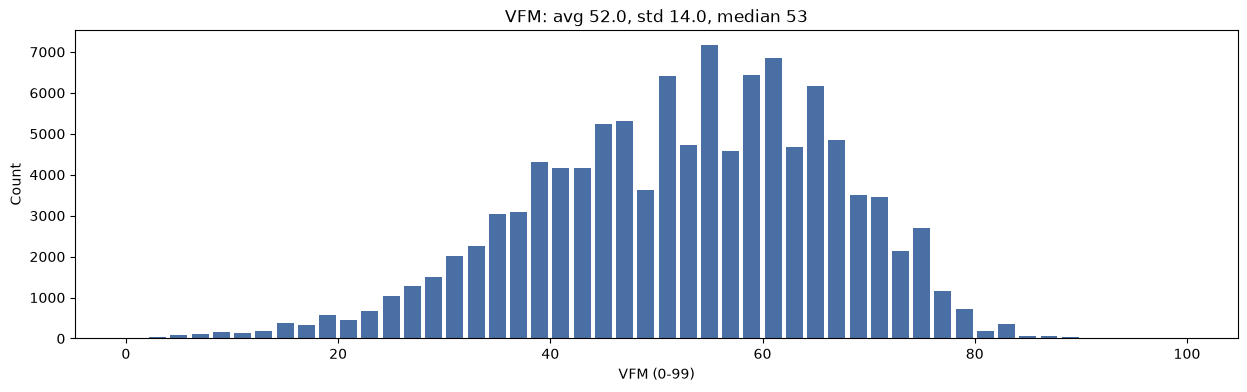

In [6]:
# ── EDA 1: the target — VFM distribution ──────────────────────────────────────
vfm_values = [w.vfm for w in wines]
plt.figure(figsize=(15, 4))
plt.title(f"VFM: avg {np.mean(vfm_values):.1f}, std {np.std(vfm_values):.1f}, "
          f"median {np.median(vfm_values):.0f}")
plt.xlabel("VFM (0-99)"); plt.ylabel("Count")
plt.hist(vfm_values, rwidth=0.8, color="#4A6FA5", bins=range(0, 101, 2))
plt.show()

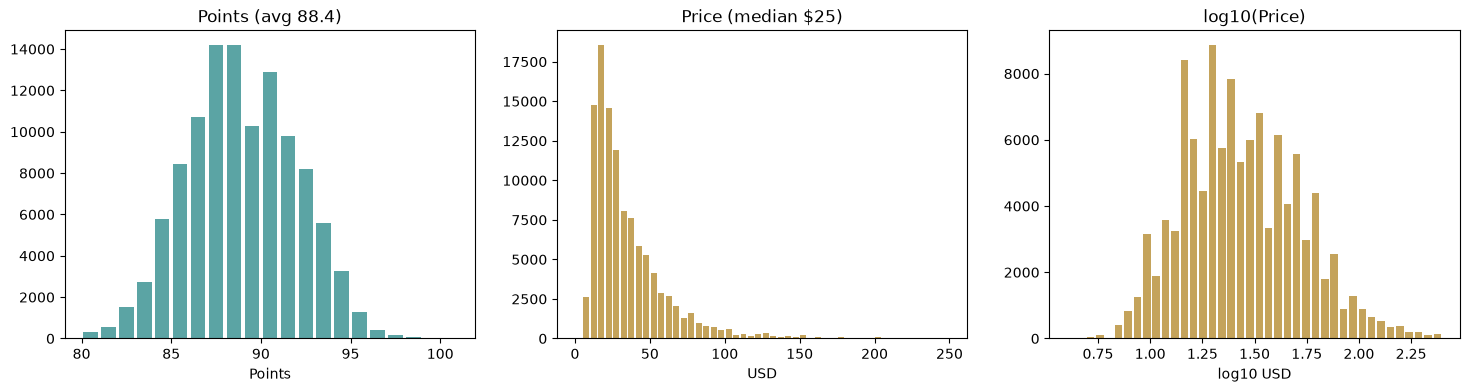

In [7]:
# ── EDA 2: source quantities — points and price ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

points = [w.points for w in wines]
axes[0].hist(points, rwidth=0.8, color="#5BA4A4", bins=range(80, 102))
axes[0].set_title(f"Points (avg {np.mean(points):.1f})"); axes[0].set_xlabel("Points")

prices = [w.price for w in wines]
axes[1].hist(prices, rwidth=0.8, color="#C4A35B", bins=range(0, 255, 5))
axes[1].set_title(f"Price (median ${np.median(prices):.0f})"); axes[1].set_xlabel("USD")

axes[2].hist(np.log10(prices), rwidth=0.8, color="#C4A35B", bins=40)
axes[2].set_title("log10(Price)")
axes[2].set_xlabel("log10 USD")
plt.show()

              median       mean  count
country                               
US              50.0  49.304741  49606
Italy           51.0  49.587259  15431
Germany         53.0  51.392894   1914
Austria         54.0  52.921344   2530
France          55.0  52.024566  15998
Australia       58.0  53.970233   2150
New Zealand     58.0  55.535599   1236
South Africa    61.0  59.104027   1192
Spain           61.0  58.085283   6027
Argentina       63.0  59.540749   3497
Portugal        63.0  60.417897   4470
Chile           65.0  62.662054   4119


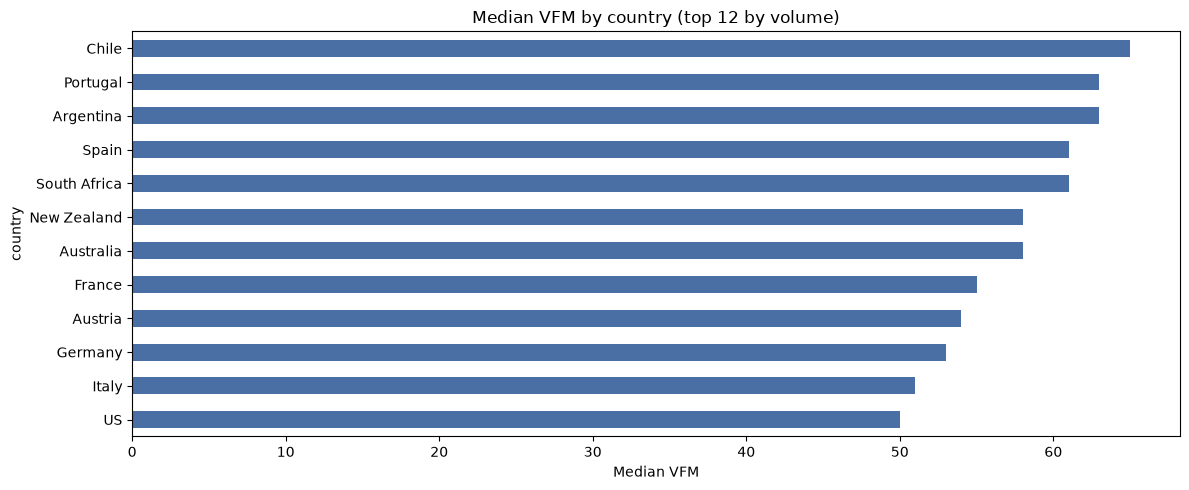

In [8]:
# ── EDA 3: VFM by country (top 12 by volume) ──────────────────────────────────
frame = pd.DataFrame(
    {
        "country": [w.country for w in wines],
        "province": [w.province for w in wines],
        "region": [w.region for w in wines],
        "variety": [w.variety for w in wines],
        "points": [w.points for w in wines],
        "price": [w.price for w in wines],
        "vfm": [w.vfm for w in wines],
    }
)

top_countries = frame["country"].value_counts().head(12).index
by_country = (
    frame[frame["country"].isin(top_countries)]
    .groupby("country")["vfm"]
    .agg(["median", "mean", "count"])
    .sort_values("median")
)
print(by_country)

by_country["median"].plot(kind="barh", figsize=(12, 5), color="#4A6FA5",
                          title="Median VFM by country (top 12 by volume)")
plt.xlabel("Median VFM")
plt.tight_layout()
plt.show()

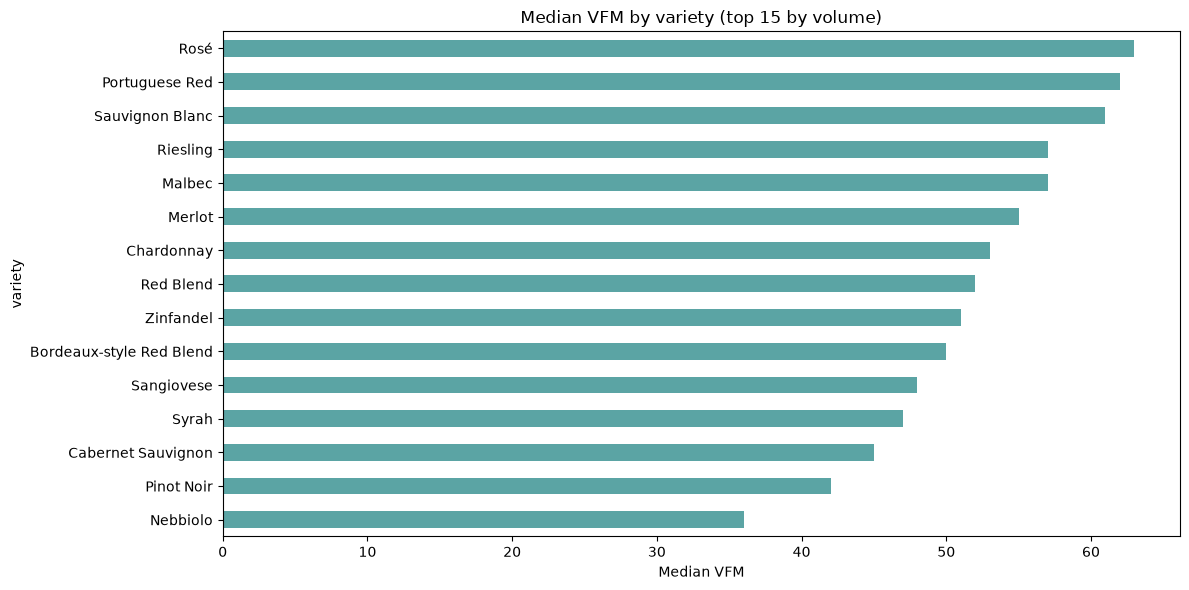

In [9]:
# ── EDA 4: VFM by grape variety (top 15 by volume) ────────────────────────────
top_varieties = frame["variety"].value_counts().head(15).index
by_variety = (
    frame[frame["variety"].isin(top_varieties)]
    .groupby("variety")["vfm"]
    .median()
    .sort_values()
)
by_variety.plot(kind="barh", figsize=(12, 6), color="#5BA4A4",
                title="Median VFM by variety (top 15 by volume)")
plt.xlabel("Median VFM")
plt.tight_layout()
plt.show()

Bottom 5 provinces by VFM:
            median  count
province                
Champagne    35.0   1245
Piedmont     39.0   2812
Burgundy     43.0   2727
Port         43.0    386
Lombardy     47.0    429 

Top 5 provinces by VFM:
                 median  count
province                     
Maule Valley      69.0    427
Lisboa            70.0    405
Central Spain     70.0    461
Central Valley    72.0    329
Vinho Verde       72.0    321 



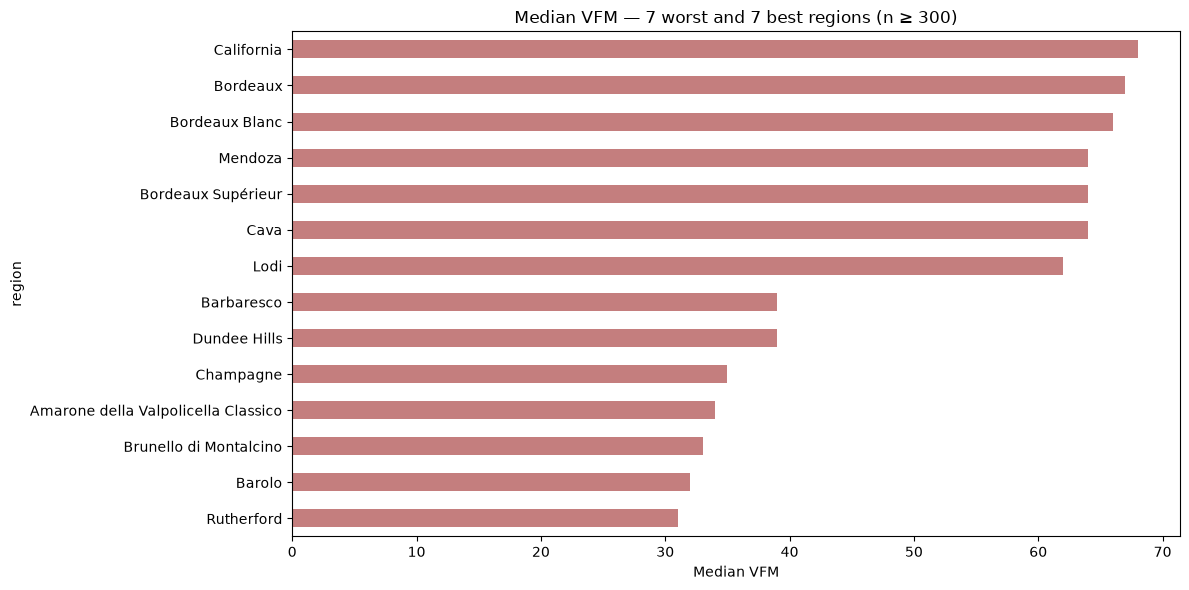

In [10]:
# ── EDA 5: best/worst VFM provinces and regions (min 300 wines) ───────────────
MIN_GROUP: int = 300

by_province = frame.groupby("province")["vfm"].agg(["median", "count"])
by_province = by_province[by_province["count"] >= MIN_GROUP].sort_values("median")
print("Bottom 5 provinces by VFM:\n", by_province.head(5), "\n")
print("Top 5 provinces by VFM:\n", by_province.tail(5), "\n")

by_region = frame[frame["region"] != "Unknown"].groupby("region")["vfm"].agg(["median", "count"])
by_region = by_region[by_region["count"] >= MIN_GROUP].sort_values("median")
combined = pd.concat([by_region.head(7), by_region.tail(7)])
combined["median"].plot(kind="barh", figsize=(12, 6), color="#C47E7E",
                        title=f"Median VFM — 7 worst and 7 best regions (n ≥ {MIN_GROUP})")
plt.xlabel("Median VFM")
plt.tight_layout()
plt.show()

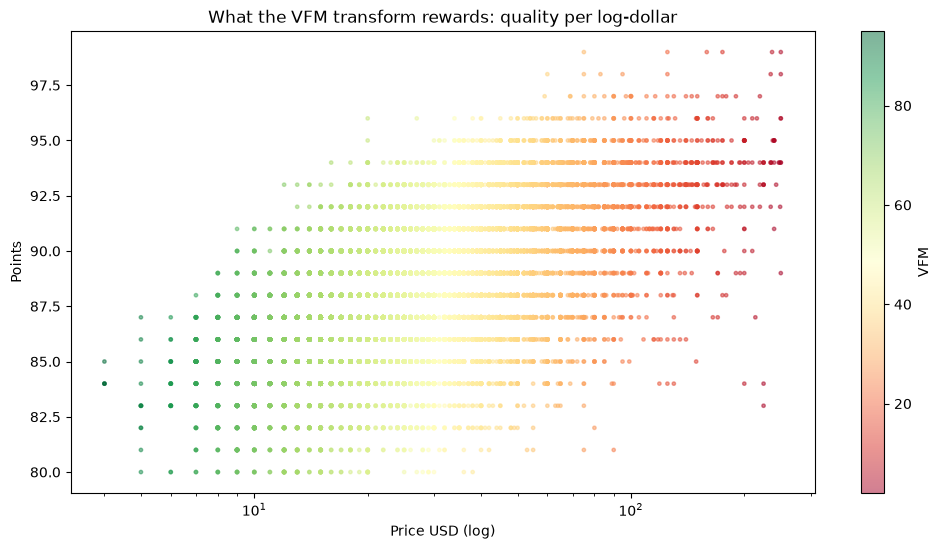

In [11]:
# ── EDA 6: the price-points plane, colored by VFM ─────────────────────────────
sample_frame = frame.sample(min(20_000, len(frame)), random_state=SEED)
plt.figure(figsize=(12, 6))
scatter = plt.scatter(sample_frame["price"], sample_frame["points"],
                      c=sample_frame["vfm"], cmap="RdYlGn", s=6, alpha=0.5)
plt.colorbar(scatter, label="VFM")
plt.xscale("log")
plt.xlabel("Price USD (log)"); plt.ylabel("Points")
plt.title("What the VFM transform rewards: quality per log-dollar")
plt.show()

In [12]:
sample: list[Wine] = wines

In [13]:
# ── Shuffle + splits, fixed seed ──────────────────────────────────────────────
random.seed(SEED)
random.shuffle(sample)
for index, wine in enumerate(sample):
    wine.id = index

n_train = int(len(sample) * TRAIN_FRACTION)
n_val = int(len(sample) * VAL_FRACTION)
train = sample[:n_train]
val = sample[n_train : n_train + n_val]
test = sample[n_train + n_val :]
print(f"train={len(train):,}  val={len(val):,}  test={len(test):,}")

# Sanity: VFM distribution should match across splits (pure function of row data)
for name, split in [("train", train), ("val", val), ("test", test)]:
    values = [w.vfm for w in split]
    print(f"{name}: VFM avg {np.mean(values):.1f}, std {np.std(values):.1f}")


train=88,320  val=11,040  test=11,041
train: VFM avg 52.0, std 14.0
val: VFM avg 52.1, std 14.1
test: VFM avg 52.2, std 13.9


## Part 2 — Pre-processing

Primary path is **deterministic assembly** (`TextAssembler`): tasting note + Variety/Country/Province/Region/Winery. Title excluded by default (`INCLUDE_TITLE=False`) — vintage + winery invite memorization leakage; flip for the ablation. The optional `LLMRewriter`/Batch path tests whether standardizing prose helps. Whichever path trains is the path that must serve at inference.

In [14]:
assembler = TextAssembler()
assembler.run(train)
assembler.run(val)
assembler.run(test)

print(train[0].prompt)
print("---")
print(test[0].test_prompt())

100%|██████████| 11041/11041 [00:00<00:00, 760440.58it/s]

What is the value-for-money score of this wine, from 0 (worst value) to 99 (best value)?

Light, fruity and juicy, this is a soft cherry-flavored wine. It has attractive acidity that lifts the warm fruitiness and gives the wine its characteristic perfumed aftertaste. Drink now.

Variety: Gamay
Country: France
Province: Beaujolais
Region: Beaujolais
Winery: Louis Jadot

Value score: 67
---
What is the value-for-money score of this wine, from 0 (worst value) to 99 (best value)?

This rusty looking PN smells roasted and stewy, with forced oak. In the mouth, this is chunky and flat. Stewy oaky plum flavors run sweet and heavy on clove, while this reverts to creamy on the finish.

Variety: Pinot Noir
Country: Chile
Province: Leyda Valley
Region: Unknown
Winery: Siegel

Value score: 


In [15]:
wines[0].model_dump()

{'title': 'Louis Jadot 2015  Beaujolais',
 'points': 86.0,
 'price': 14.0,
 'vfm': 67,
 'country': 'France',
 'province': 'Beaujolais',
 'region': 'Beaujolais',
 'variety': 'Gamay',
 'winery': 'Louis Jadot',
 'full': 'Light, fruity and juicy, this is a soft cherry-flavored wine. It has attractive acidity that lifts the warm fruitiness and gives the wine its characteristic perfumed aftertaste. Drink now.',
 'summary': 'Light, fruity and juicy, this is a soft cherry-flavored wine. It has attractive acidity that lifts the warm fruitiness and gives the wine its characteristic perfumed aftertaste. Drink now.\n\nVariety: Gamay\nCountry: France\nProvince: Beaujolais\nRegion: Beaujolais\nWinery: Louis Jadot',
 'prompt': 'What is the value-for-money score of this wine, from 0 (worst value) to 99 (best value)?\n\nLight, fruity and juicy, this is a soft cherry-flavored wine. It has attractive acidity that lifts the warm fruitiness and gives the wine its characteristic perfumed aftertaste. Drink n

In [16]:
# ── OPTIONAL ablation: LLM rewrite on a slice, then re-evaluate later ─────────
# rewriter = LLMRewriter()
# rewriter.run(train[:1000])
# For scale, use wine_critic/batch.py (Batch API, ~50% cheaper; match by custom_id).

In [17]:
# ── OPTIONAL: push the curated dataset to the Hub (license: CC BY-NC-SA 4.0) ──
# Wine.push_to_hub(HUB_DATASET_NAME, train, val, test)

## Part 3 — Evaluation Harness, Baselines, Traditional ML

One harness (`utils/evaluator.py`): **MAE ± 95% CI and R²** on the same held-out slice, bands green < 5 / orange < 15 on the 0–99 scale. Ladder: random → constant → feature LR → bag-of-words LR → Random Forest → XGBoost.

In [18]:
def random_vfm(wine: Wine) -> float:
    """Uniform random guess across the VFM scale."""
    return random.uniform(0, 99)

random.seed(SEED)
evaluate(random_vfm, test)

1: Guess 63 Truth 66 Error 3
2: Guess 2 Truth 46 Error 44
3: Guess 27 Truth 76 Error 49
4: Guess 22 Truth 75 Error 53
5: Guess 73 Truth 68 Error 5
6: Guess 67 Truth 57 Error 10
7: Guess 88 Truth 34 Error 54
8: Guess 9 Truth 74 Error 65
9: Guess 42 Truth 42 Error 0
10: Guess 3 Truth 64 Error 61
11: Guess 22 Truth 43 Error 21
12: Guess 50 Truth 49 Error 1
13: Guess 3 Truth 48 Error 45
14: Guess 20 Truth 64 Error 44
15: Guess 64 Truth 33 Error 31
16: Guess 54 Truth 36 Error 18
17: Guess 22 Truth 31 Error 9
18: Guess 58 Truth 66 Error 8
19: Guess 80 Truth 52 Error 28
20: Guess 1 Truth 54 Error 53
21: Guess 80 Truth 47 Error 33
22: Guess 69 Truth 57 Error 12
23: Guess 34 Truth 55 Error 21
24: Guess 15 Truth 74 Error 59
25: Guess 95 Truth 24 Error 71
26: Guess 33 Truth 76 Error 43
27: Guess 9 Truth 39 Error 30
28: Guess 10 Truth 50 Error 40
29: Guess 84 Truth 46 Error 38
30: Guess 60 Truth 29 Error 31
31: Guess 80 Truth 52 Error 28
32: Guess 72 Truth 70 Error 2
33: Guess 53 Truth 41 Error 12

In [19]:
TRAIN_MEAN_VFM: float = float(np.mean([w.vfm for w in train]))

def constant_vfm(wine: Wine) -> float:
    """Always predict the training-set mean — the honest floor."""
    return TRAIN_MEAN_VFM

evaluate(constant_vfm, test)

1: Guess 52 Truth 66 Error 14
2: Guess 52 Truth 46 Error 6
3: Guess 52 Truth 76 Error 24
4: Guess 52 Truth 75 Error 23
5: Guess 52 Truth 68 Error 16
6: Guess 52 Truth 57 Error 5
7: Guess 52 Truth 34 Error 18
8: Guess 52 Truth 74 Error 22
9: Guess 52 Truth 42 Error 10
10: Guess 52 Truth 64 Error 12
11: Guess 52 Truth 43 Error 9
12: Guess 52 Truth 49 Error 3
13: Guess 52 Truth 48 Error 4
14: Guess 52 Truth 64 Error 12
15: Guess 52 Truth 33 Error 19
16: Guess 52 Truth 36 Error 16
17: Guess 52 Truth 31 Error 21
18: Guess 52 Truth 66 Error 14
19: Guess 52 Truth 52 Error 0
20: Guess 52 Truth 54 Error 2
21: Guess 52 Truth 47 Error 5
22: Guess 52 Truth 57 Error 5
23: Guess 52 Truth 55 Error 3
24: Guess 52 Truth 74 Error 22
25: Guess 52 Truth 24 Error 28
26: Guess 52 Truth 76 Error 24
27: Guess 52 Truth 39 Error 13
28: Guess 52 Truth 50 Error 2
29: Guess 52 Truth 46 Error 6
30: Guess 52 Truth 29 Error 23
31: Guess 52 Truth 52 Error 0
32: Guess 52 Truth 70 Error 18
33: Guess 52 Truth 41 Error 11

In [20]:
# ── Engineered features + linear regression ───────────────────────────────────
from sklearn.linear_model import LinearRegression

TOP_N_CATEGORY: int = 5

TOP_COUNTRIES: list[str] = (
    pd.Series([w.country for w in train]).value_counts().head(TOP_N_CATEGORY).index.tolist()
)
TOP_VARIETIES: list[str] = (
    pd.Series([w.variety for w in train]).value_counts().head(TOP_N_CATEGORY).index.tolist()
)
print(f"Top countries: {TOP_COUNTRIES}")
print(f"Top varieties: {TOP_VARIETIES}")


def get_features(wine: Wine) -> dict[str, float]:
    """Note length + top-5 country one-hot + top-5 variety one-hot.
    Anything outside the top 5 falls to all-zeros (implicit 'other' bucket).
    NOTE: price/points are excluded — they ARE the label."""
    features = {"note_length": float(len(wine.full))}
    for country in TOP_COUNTRIES:
        features[f"country_{country}"] = float(wine.country == country)
    for variety in TOP_VARIETIES:
        features[f"variety_{variety}"] = float(wine.variety == variety)
    return features


np.random.seed(SEED)
feature_columns = list(get_features(train[0]).keys())
train_frame = pd.DataFrame([get_features(w) for w in train])
train_frame["vfm"] = [w.vfm for w in train]
feature_lr = LinearRegression().fit(train_frame[feature_columns], train_frame["vfm"])
for column, coef in zip(feature_columns, feature_lr.coef_):
    print(f"{column}: {coef:.4f}")


def feature_linear_regression(wine: Wine) -> float:
    """Predict VFM from note length + top-5 country/variety one-hot."""
    row = pd.DataFrame([get_features(wine)])
    return float(feature_lr.predict(row[feature_columns])[0])


evaluate(feature_linear_regression, test)

Top countries: ['US', 'France', 'Italy', 'Spain', 'Portugal']
Top varieties: ['Pinot Noir', 'Chardonnay', 'Cabernet Sauvignon', 'Red Blend', 'Bordeaux-style Red Blend']
note_length: -0.0749
country_US: -6.7437
country_France: -6.8189
country_Italy: -9.8135
country_Spain: -0.3734
country_Portugal: -0.7853
variety_Pinot Noir: -8.4599
variety_Chardonnay: -2.2911
variety_Cabernet Sauvignon: -7.7141
variety_Red Blend: -1.0137
variety_Bordeaux-style Red Blend: -4.3741
1: Guess 54 Truth 66 Error 12
2: Guess 43 Truth 46 Error 3
3: Guess 54 Truth 76 Error 22
4: Guess 54 Truth 75 Error 21
5: Guess 62 Truth 68 Error 6
6: Guess 47 Truth 57 Error 10
7: Guess 36 Truth 34 Error 2
8: Guess 59 Truth 74 Error 15
9: Guess 46 Truth 42 Error 4
10: Guess 47 Truth 64 Error 17
11: Guess 52 Truth 43 Error 9
12: Guess 53 Truth 49 Error 4
13: Guess 53 Truth 48 Error 5
14: Guess 57 Truth 64 Error 7
15: Guess 56 Truth 33 Error 23
16: Guess 45 Truth 36 Error 9
17: Guess 50 Truth 31 Error 19
18: Guess 53 Truth 66 Er

In [21]:
# ── Bag of words + linear regression (text only) ──────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer

np.random.seed(SEED)
train_targets = np.array([w.vfm for w in train], dtype=float)
vectorizer = CountVectorizer(max_features=2000, stop_words="english")
train_matrix = vectorizer.fit_transform([w.summary for w in train])
bow_lr = LinearRegression().fit(train_matrix, train_targets)

def bow_linear_regression(wine: Wine) -> float:
    """Predict VFM from bag-of-words over the assembled text."""
    return float(bow_lr.predict(vectorizer.transform([wine.summary]))[0])

evaluate(bow_linear_regression, test)

1: Guess 57 Truth 66 Error 92: Guess 48 Truth 46 Error 2
3: Guess 53 Truth 76 Error 23
4: Guess 62 Truth 75 Error 13
5: Guess 68 Truth 68 Error 0
6: Guess 50 Truth 57 Error 7
7: Guess 24 Truth 34 Error 10
8: Guess 68 Truth 74 Error 6
9: Guess 42 Truth 42 Error 0
10: Guess 49 Truth 64 Error 15
11: Guess 47 Truth 43 Error 4
12: Guess 58 Truth 49 Error 9
13: Guess 45 Truth 48 Error 3
14: Guess 66 Truth 64 Error 2
15: Guess 50 Truth 33 Error 17
16: Guess 35 Truth 36 Error 1
17: Guess 47 Truth 31 Error 16
18: Guess 55 Truth 66 Error 11

19: Guess 46 Truth 52 Error 6
20: Guess 48 Truth 54 Error 6
21: Guess 45 Truth 47 Error 2
22: Guess 53 Truth 57 Error 4
23: Guess 63 Truth 55 Error 8
24: Guess 61 Truth 74 Error 13
25: Guess 36 Truth 24 Error 12
26: Guess 76 Truth 76 Error 0
27: Guess 34 Truth 39 Error 5
28: Guess 57 Truth 50 Error 7
29: Guess 51 Truth 46 Error 5
30: Guess 38 Truth 29 Error 9
31: Guess 49 Truth 52 Error 3
32: Guess 76 Truth 70 Error 6
33: Guess 51 Truth 41 Error 10
34: Guess

In [22]:
# ── Combined features: bag-of-words + top-5 country/variety dummies ──────────
from scipy.sparse import csr_matrix, hstack

def get_dummy_features(wine: Wine) -> dict[str, float]:
    """Top-5 country/variety one-hot — frozen categories from TOP_COUNTRIES/TOP_VARIETIES."""
    features = {}
    for country in TOP_COUNTRIES:
        features[f"country_{country}"] = float(wine.country == country)
    for variety in TOP_VARIETIES:
        features[f"variety_{variety}"] = float(wine.variety == variety)
    return features

dummy_columns = list(get_dummy_features(train[0]).keys())

def to_combined(wines: list[Wine]) -> csr_matrix:
    """BoW text matrix + categorical dummies, hstacked into one sparse matrix."""
    text_features = vectorizer.transform([w.summary for w in wines])
    dummy_rows = csr_matrix(
        pd.DataFrame([get_dummy_features(w) for w in wines])[dummy_columns].values
    )
    return hstack([text_features, dummy_rows]).tocsr()

train_combined = to_combined(train)

In [23]:
# ── Bag-of-words + dummies, linear regression ─────────────────────────────────
bow_lr_combined = LinearRegression().fit(train_combined, train_targets)

def bow_linear_regression_combined(wine: Wine) -> float:
    return float(bow_lr_combined.predict(to_combined([wine]))[0])

evaluate(bow_linear_regression_combined, test)

1: Guess 55 Truth 66 Error 112: Guess 48 Truth 46 Error 2

3: Guess 55 Truth 76 Error 21
4: Guess 61 Truth 75 Error 14
5: Guess 68 Truth 68 Error 0
6: Guess 51 Truth 57 Error 6
7: Guess 24 Truth 34 Error 10
8: Guess 70 Truth 74 Error 4
9: Guess 41 Truth 42 Error 1
10: Guess 48 Truth 64 Error 16
11: Guess 48 Truth 43 Error 5
12: Guess 58 Truth 49 Error 9
13: Guess 45 Truth 48 Error 3
14: Guess 67 Truth 64 Error 3
15: Guess 50 Truth 33 Error 17
16: Guess 33 Truth 36 Error 3
17: Guess 47 Truth 31 Error 16
18: Guess 55 Truth 66 Error 11
19: Guess 46 Truth 52 Error 6
20: Guess 48 Truth 54 Error 6
21: Guess 45 Truth 47 Error 2
22: Guess 54 Truth 57 Error 3
23: Guess 64 Truth 55 Error 9
24: Guess 62 Truth 74 Error 12
25: Guess 36 Truth 24 Error 12
26: Guess 75 Truth 76 Error 1
27: Guess 34 Truth 39 Error 5
28: Guess 57 Truth 50 Error 7
29: Guess 51 Truth 46 Error 5
30: Guess 37 Truth 29 Error 8
31: Guess 49 Truth 52 Error 3
32: Guess 77 Truth 70 Error 7
33: Guess 52 Truth 41 Error 11
34: Gues

In [24]:
# ── Bag-of-words + dummies, Random Forest (RF_SUBSET cap) ────────────────
from sklearn.ensemble import RandomForestRegressor

RF_SUBSET: int = 30_000
rf_combined_model = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=10)
rf_combined_model.fit(train_combined[:RF_SUBSET], train_targets[:RF_SUBSET])

def random_forest_combined(wine: Wine) -> float:
    return float(rf_combined_model.predict(to_combined([wine]))[0])

evaluate(random_forest_combined, test)

1: Guess 61 Truth 66 Error 5
6: Guess 50 Truth 57 Error 7
3: Guess 61 Truth 76 Error 15
5: Guess 65 Truth 68 Error 3
4: Guess 60 Truth 75 Error 15
7: Guess 41 Truth 34 Error 7
8: Guess 65 Truth 74 Error 9
9: Guess 36 Truth 42 Error 6
10: Guess 53 Truth 64 Error 11
2: Guess 45 Truth 46 Error 1
11: Guess 57 Truth 43 Error 14
12: Guess 53 Truth 49 Error 4
13: Guess 48 Truth 48 Error 0
14: Guess 59 Truth 64 Error 5
15: Guess 51 Truth 33 Error 18
18: Guess 61 Truth 66 Error 5
19: Guess 45 Truth 52 Error 7
16: Guess 36 Truth 36 Error 0
17: Guess 51 Truth 31 Error 20
23: Guess 58 Truth 55 Error 3
21: Guess 51 Truth 47 Error 4
20: Guess 56 Truth 54 Error 2
25: Guess 44 Truth 24 Error 20
22: Guess 56 Truth 57 Error 1
24: Guess 63 Truth 74 Error 11
28: Guess 52 Truth 50 Error 2
26: Guess 72 Truth 76 Error 4
30: Guess 32 Truth 29 Error 3
29: Guess 54 Truth 46 Error 8
31: Guess 56 Truth 52 Error 4
34: Guess 62 Truth 61 Error 1
32: Guess 63 Truth 70 Error 7
27: Guess 39 Truth 39 Error 0
33: Guess 5

## Part 4 — Deep Neural Network + Frontier LLMa

The DNN lives in `utils/deep_neural_network.py` — residual bag-of-words
regressor, plain standardization. For the frontier, the **composite path** is
primary: the model estimates points and price (quantities that exist in the
world), and the SAME frozen `compute_vfm` maps them to 0–99 — a fair ladder
comparison. A direct "guess the 0–99 score" variant is included for contrast;
expect it to be weaker since VFM is our construct, not world knowledge.


In [25]:
trainer = VfmTrainer()
trainer.train(train)

Regenerated constants -> Y_MEAN=51.9933  Y_STD=14.0466


Epoch 1: 100%|██████████| 345/345 [00:06<00:00, 55.55it/s]


Epoch 1: loss 0.6753


Epoch 2: 100%|██████████| 345/345 [00:05<00:00, 58.51it/s]


Epoch 2: loss 0.3362


...

Epoch 8: loss 0.0111


Epoch 9: 100%|██████████| 345/345 [00:05<00:00, 59.10it/s]


Epoch 9: loss 0.0064


Epoch 10: 100%|██████████| 345/345 [00:05<00:00, 60.08it/s]

Epoch 10: loss 0.0049


In [26]:
def neural_network(wine: Wine) -> float:
    """Predict VFM with the trained DNN."""
    return trainer.predict(wine)

evaluate(neural_network, test)

1: Guess 63 Truth 66 Error 34: Guess 62 Truth 75 Error 13

6: Guess 59 Truth 57 Error 2
3: Guess 61 Truth 76 Error 15
2: Guess 46 Truth 46 Error 0
8: Guess 76 Truth 74 Error 2
7: Guess 36 Truth 34 Error 2
9: Guess 46 Truth 42 Error 4
5: Guess 66 Truth 68 Error 2
10: Guess 60 Truth 64 Error 4
14: Guess 71 Truth 64 Error 7
13: Guess 50 Truth 48 Error 2
12: Guess 57 Truth 49 Error 8
11: Guess 52 Truth 43 Error 9
20: Guess 53 Truth 54 Error 1
17: Guess 57 Truth 31 Error 26
15: Guess 45 Truth 33 Error 12
19: Guess 44 Truth 52 Error 8
16: Guess 25 Truth 36 Error 11
18: Guess 61 Truth 66 Error 5
23: Guess 68 Truth 55 Error 13
21: Guess 46 Truth 47 Error 1
25: Guess 40 Truth 24 Error 16
27: Guess 39 Truth 39 Error 0
26: Guess 76 Truth 76 Error 0
29: Guess 54 Truth 46 Error 8
24: Guess 72 Truth 74 Error 2
28: Guess 51 Truth 50 Error 1
22: Guess 54 Truth 57 Error 3
30: Guess 39 Truth 29 Error 10
33: Guess 44 Truth 41 Error 3
32: Guess 73 Truth 70 Error 3
31: Guess 50 Truth 52 Error 2
36: Guess 3

In [27]:
def composite_messages_for(wine: Wine) -> list[dict[str, str]]:
    """Frontier prompt: estimate points and price as JSON."""
    instruction = (
        "Estimate this wine's Wine Enthusiast critic score (80-100 points) "
        "and its retail price in USD from the tasting note and details. "
        'Respond ONLY with JSON: {"points": <int>, "price": <float>}'
    )
    return [{"role": "user", "content": f"{instruction}\n\n{wine.summary}"}]


def frontier_composite(wine: Wine) -> float:
    """Frontier estimates (points, price); frozen compute_vfm maps to 0-99."""
    response = client.chat.completions.create(
        model=FRONTIER_MODEL,
        messages=composite_messages_for(wine),
        max_tokens=40,
    )
    reply = response.choices[0].message.content.replace("```json", "").replace("```", "")
    try:
        estimate = json.loads(reply)
        points = float(np.clip(estimate["points"], 80, 100))
        price = float(np.clip(estimate["price"], 4, 250))
        return float(compute_vfm(points, price))
    except (json.JSONDecodeError, KeyError, TypeError, ValueError):
        return TRAIN_MEAN_VFM  # graceful fallback on malformed output

In [28]:
print(test[0].summary)
print(frontier_composite(test[0]), "vs truth", test[0].vfm)

This rusty looking PN smells roasted and stewy, with forced oak. In the mouth, this is chunky and flat. Stewy oaky plum flavors run sweet and heavy on clove, while this reverts to creamy on the finish.

Variety: Pinot Noir
Country: Chile
Province: Leyda Valley
Region: Unknown
Winery: Siegel
69.0 vs truth 66


In [29]:
evaluate(frontier_composite, test)

1: Guess 69 Truth 66 Error 3
9: Guess 41 Truth 42 Error 1
7: Guess 36 Truth 34 Error 2
6: Guess 59 Truth 57 Error 2
10: Guess 61 Truth 64 Error 3
8: Guess 74 Truth 74 Error 0
2: Guess 45 Truth 46 Error 1
5: Guess 70 Truth 68 Error 2
4: Guess 63 Truth 75 Error 12
3: Guess 69 Truth 76 Error 7
12: Guess 57 Truth 49 Error 8
14: Guess 64 Truth 64 Error 0
15: Guess 43 Truth 33 Error 10
17: Guess 71 Truth 31 Error 40
11: Guess 61 Truth 43 Error 18
13: Guess 50 Truth 48 Error 2
18: Guess 68 Truth 66 Error 2
16: Guess 39 Truth 36 Error 3
19: Guess 42 Truth 52 Error 10
20: Guess 58 Truth 54 Error 4
21: Guess 48 Truth 47 Error 1
26: Guess 70 Truth 76 Error 6
24: Guess 72 Truth 74 Error 2
28: Guess 60 Truth 50 Error 10
23: Guess 65 Truth 55 Error 10
25: Guess 42 Truth 24 Error 18
22: Guess 64 Truth 57 Error 7
27: Guess 44 Truth 39 Error 5
29: Guess 56 Truth 46 Error 10
30: Guess 33 Truth 29 Error 4
32: Guess 72 Truth 70 Error 2
33: Guess 42 Truth 41 Error 1
31: Guess 61 Truth 52 Error 9
34: Guess 

## Part 5 — Fine-Tuning a Frontier Model

OpenAI SFT on the VFM target directly — unlike zero-shot, a fine-tune CAN learn our construct from examples, which is exactly the point of this rung. 200 train / 50 validation, 1 epoch. The assistant turn goes in TRAINING JSONL only.

In [30]:
FINE_TUNE_TRAIN_SIZE: int = 200
FINE_TUNE_VAL_SIZE: int = 50

fine_tune_train = train[:FINE_TUNE_TRAIN_SIZE]
fine_tune_validation = val[:FINE_TUNE_VAL_SIZE]

In [31]:
# ── Contrast: ask for the 0-99 score directly (expected weaker) ───────────────
def direct_messages_for(wine: Wine) -> list[dict[str, str]]:
    """Frontier prompt: guess the 0-99 VFM score directly."""
    instruction = (
        "Rate this wine's value-for-money from 0 (worst value) to 99 (best "
        "value), where the score reflects quality relative to price. "
        "Respond only with the number."
    )
    return [{"role": "user", "content": f"{instruction}\n\n{wine.summary}"}]


def frontier_direct(wine: Wine) -> str:
    """Direct 0-99 guess — our construct, not world knowledge."""
    response = client.chat.completions.create(
        model=FRONTIER_MODEL, messages=direct_messages_for(wine), max_tokens=10
    )
    return response.choices[0].message.content

evaluate(frontier_direct, test)

9: Guess 78 Truth 42 Error 36
7: Guess 73 Truth 34 Error 39
4: Guess 87 Truth 75 Error 12
2: Guess 89 Truth 46 Error 43
6: Guess 85 Truth 57 Error 28
8: Guess 71 Truth 74 Error 3
3: Guess 68 Truth 76 Error 8
1: Guess 35 Truth 66 Error 31
10: Guess 85 Truth 64 Error 21
5: Guess 81 Truth 68 Error 13
12: Guess 81 Truth 49 Error 32
13: Guess 47 Truth 48 Error 1
14: Guess 85 Truth 64 Error 21
11: Guess 54 Truth 43 Error 11
20: Guess 86 Truth 54 Error 32
15: Guess 87 Truth 33 Error 54
18: Guess 72 Truth 66 Error 6
19: Guess 88 Truth 52 Error 36
17: Guess 42 Truth 31 Error 11
16: Guess 87 Truth 36 Error 51
22: Guess 86 Truth 57 Error 29
24: Guess 52 Truth 74 Error 22
23: Guess 87 Truth 55 Error 32
29: Guess 62 Truth 46 Error 16
21: Guess 82 Truth 47 Error 35
30: Guess 88 Truth 29 Error 59
26: Guess 77 Truth 76 Error 1
28: Guess 76 Truth 50 Error 26
25: Guess 87 Truth 24 Error 63
27: Guess 88 Truth 39 Error 49
31: Guess 73 Truth 52 Error 21
32: Guess 83 Truth 70 Error 13
35: Guess 82 Truth 59 

In [32]:
def training_messages_for(wine: Wine) -> list[dict[str, str]]:
    """User prompt + expected assistant answer — TRAINING JSONL ONLY."""
    return direct_messages_for(wine) + [
        {"role": "assistant", "content": f"{wine.vfm}"}
    ]


def write_jsonl(wines: list[Wine], filename: str) -> None:
    """Write fine-tuning JSONL: one messages object per line."""
    with open(filename, "w", encoding="utf-8") as f:
        for wine in wines:
            f.write(json.dumps({"messages": training_messages_for(wine)}) + "\n")


write_jsonl(fine_tune_train, "fine_tune_train.jsonl")
write_jsonl(fine_tune_validation, "fine_tune_validation.jsonl")

In [33]:
with open("fine_tune_train.jsonl", "rb") as f:
    train_file = client.files.create(file=f, purpose="fine-tune")
with open("fine_tune_validation.jsonl", "rb") as f:
    validation_file = client.files.create(file=f, purpose="fine-tune")
train_file, validation_file

(FileObject(id='file-LQrqK5qFWCnDCo2p3hgj9Z', bytes=121139, created_at=1783166453, filename='fine_tune_train.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None),
 FileObject(id='file-P1LZnDpz54Gf8n8xWGyPxG', bytes=29798, created_at=1783166454, filename='fine_tune_validation.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None))

## OpenAI shut down self-serve fine-tuning entirely, so this section is now a placeholder. The code is still here for reference, but it will not run.

In [ ]:
job = client.fine_tuning.jobs.create(
    training_file=train_file.id,
    validation_file=validation_file.id,
    model=FINE_TUNE_BASE_MODEL,
    seed=SEED,
    hyperparameters={"n_epochs": 1, "batch_size": 1},
    suffix="wine-vfm",
)
job.id

In [ ]:
# Poll until status == 'succeeded'
client.fine_tuning.jobs.retrieve(job.id)


In [ ]:
client.fine_tuning.jobs.list_events(fine_tuning_job_id=job.id, limit=10).data

In [ ]:
fine_tuned_model_name = client.fine_tuning.jobs.retrieve(job.id).fine_tuned_model
fine_tuned_model_name


In [ ]:
def fine_tuned_frontier(wine: Wine) -> str:
    """VFM estimate from the fine-tuned model — inference messages only."""
    response = client.chat.completions.create(
        model=fine_tuned_model_name,
        messages=direct_messages_for(wine),
        max_tokens=7,
    )
    return response.choices[0].message.content

In [ ]:
print(test[0].vfm)
print(fine_tuned_frontier(test[0]))

In [ ]:
evaluate(fine_tuned_frontier, test)